# 获取数据

In [4]:
# import os
# import urllib.request
# import pandas as pd
# import zipfile

# def download_ccpp_dataset():
#     # 数据集URL
#     url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip"
    
#     # 本地保存路径
#     data_dir = "data"
#     zip_file = os.path.join(data_dir, "CCPP.zip")
#     csv_file = os.path.join(data_dir, "CCPP_data.csv")
    
#     # 创建data目录（如果不存在）
#     os.makedirs(data_dir, exist_ok=True)
    
#     try:
#         # 下载数据集
#         print("开始下载联合循环发电厂数据集...")
#         urllib.request.urlretrieve(url, zip_file)
#         print("数据集下载完成！")
        
#         # 解压并处理ZIP文件中的内容
#         print("正在处理数据集...")
#         with zipfile.ZipFile(zip_file, 'r') as zip_ref:
#             # 列出ZIP文件中的所有内容
#             file_list = zip_ref.namelist()
#             print(f"ZIP文件包含以下内容: {file_list}")
            
#             # 寻找Excel数据文件
#             data_files = [f for f in file_list if f.endswith('.xlsx') or f.endswith('.ods')]
#             if not data_files:
#                 raise Exception("未找到数据文件")
                
#             # 取第一个数据文件
#             data_file = data_files[0]
#             print(f"使用数据文件: {data_file}")
            
#             # 读取Excel文件
#             with zip_ref.open(data_file) as f:
#                 # 对于ods文件，pandas需要odf库支持
#                 if data_file.endswith('.ods'):
#                     df = pd.read_excel(f, engine='odf')
#                 else:
#                     df = pd.read_excel(f)
        
#         # 保存为CSV文件
#         df.to_csv(csv_file, index=False)
#         print(f"数据集已保存到 {csv_file}")
        
#         # 清理临时文件
#         os.remove(zip_file)
#         print("临时压缩文件已删除")
        
#         return df
        
#     except Exception as e:
#         print(f"发生错误: {e}")
#         return None

# if __name__ == "__main__":
#     # 下载并获取数据集
#     dataset = download_ccpp_dataset()
    
#     # 如果成功获取数据集，打印基本信息
#     if dataset is not None:
#         print("\n数据集基本信息：")
#         print(f"样本数量: {dataset.shape[0]}")
#         print(f"特征数量: {dataset.shape[1]}")
#         print("\n前5行数据:")
#         print(dataset.head())
    

开始下载联合循环发电厂数据集...
数据集下载完成！
正在处理数据集...
ZIP文件包含以下内容: ['CCPP/', 'CCPP/Folds5x2_pp.ods', 'CCPP/Folds5x2_pp.xlsx', 'CCPP/Readme.txt', 'CCPP/Readme.txt~']
使用数据文件: CCPP/Folds5x2_pp.ods
数据集已保存到 data\CCPP_data.csv
临时压缩文件已删除

数据集基本信息：
样本数量: 9568
特征数量: 5

前5行数据:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


# 读取数据

In [7]:
import pandas as pd
ccpp_data = pd.read_csv('data\CCPP_data.csv')
print(ccpp_data[:3])
x = ccpp_data.iloc[:,:4].values.astype(float)
y = ccpp_data.iloc[:,-1:].values.astype(float)
print(x.shape)
print(y.shape)
print(x[:3])
print(y[:3])

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
(9568, 4)
(9568, 1)
[[  14.96   41.76 1024.07   73.17]
 [  25.18   62.96 1020.04   59.08]
 [   5.11   39.4  1012.16   92.14]]
[[463.26]
 [444.37]
 [488.56]]


# 划分训练集和测试集

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)

(7654, 4)
(1914, 4)


# 观察数据的基本关系

In [12]:
import numpy as np
import matplotlib.pyplot as plt
train_array = np.hstack((x_train,y_train))
train_df = pd.DataFrame(train_array,columns = ccpp_data.columns)
#通过corr()方法计算每个属性的相关性
corr_matrix = train_df.corr()
print('皮尔逊系数矩阵:\n',corr_matrix)
#查看各个特征属性与目标属性之间的相关性
print('各特征属性与每小时电量输出之间的关系:\n',corr_matrix['PE'].sort_values(ascending = False),sep = '')

皮尔逊系数矩阵:
           AT         V        AP        RH        PE
AT  1.000000  0.843641 -0.509377 -0.542002 -0.947326
V   0.843641  1.000000 -0.415380 -0.308910 -0.869854
AP -0.509377 -0.415380  1.000000  0.102791  0.519938
RH -0.542002 -0.308910  0.102791  1.000000  0.387859
PE -0.947326 -0.869854  0.519938  0.387859  1.000000
各特征属性与每小时电量输出之间的关系:
PE    1.000000
AP    0.519938
RH    0.387859
V    -0.869854
AT   -0.947326
Name: PE, dtype: float64


In [13]:
#绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] - False
d = {'AT':'环境温度','AP':'环境压力','RH':'相对湿度','V':'排气真空程度','PE':'输出电能'}
y_col_name = ccpp_data.columns[-1:][0]

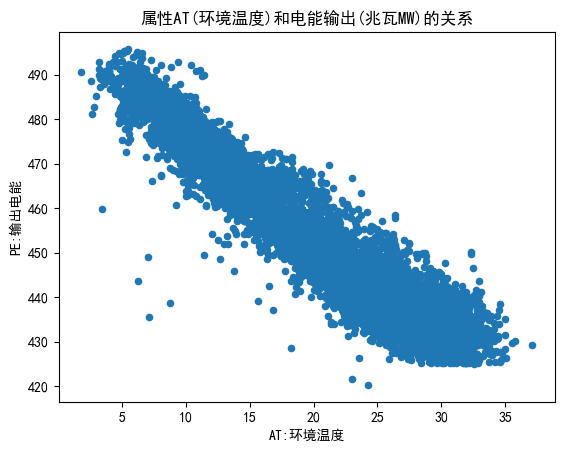

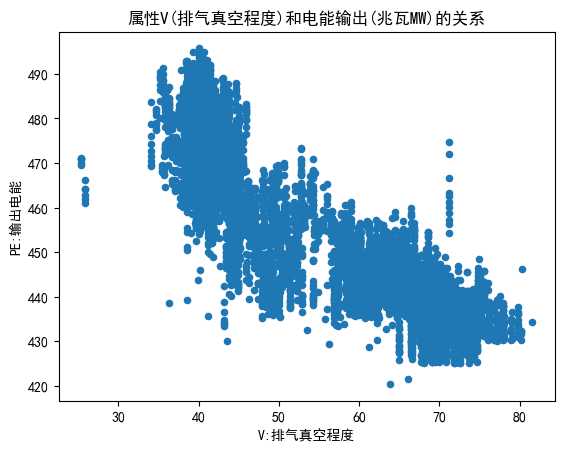

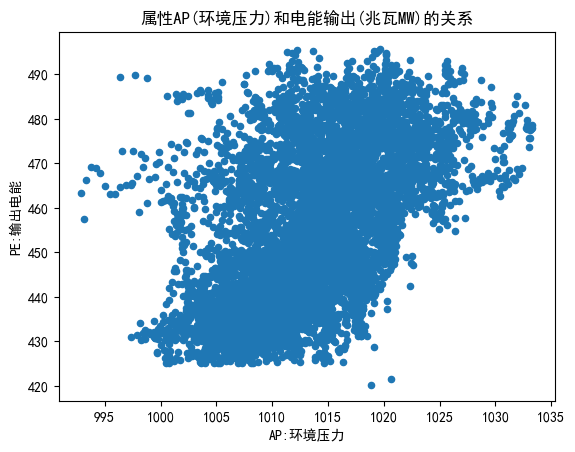

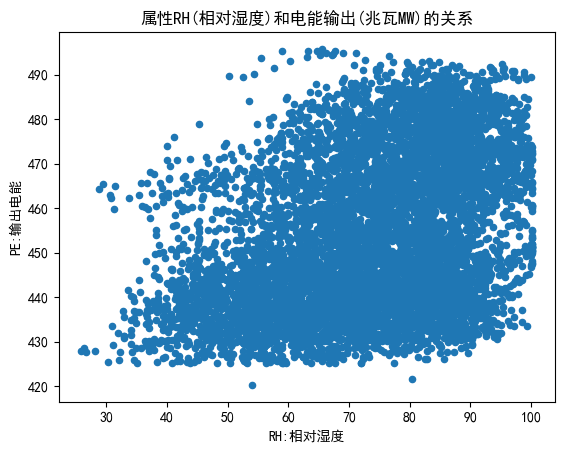

In [19]:
# 遍历数据集中除最后一列外的所有特征列（假设最后一列是目标变量）
for col in ccpp_data.columns[:-1]:
    # 绘制散点图：x轴为当前特征列，y轴为目标变量列
    # 设置图表标题，包含特征名称及其对应的描述信息
    train_df.plot(kind='scatter', x=col, y=y_col_name, 
                  title=f'属性{col}({d[col]})和电能输出(兆瓦MW)的关系')
    
    # 设置x轴标签，包含特征名称及其描述
    plt.xlabel(xlabel=f'{col}:{d[col]}')
    
    # 设置y轴标签，包含目标变量名称及其描述
    plt.ylabel(ylabel=f'{y_col_name}:{d[y_col_name]}')

# 以线性回归为例来训练模型

In [18]:
#建立自变量特征值与目标变量
from sklearn.linear_model import LinearRegression
m = LinearRegression()
m.fit(x_train,y_train)
#输出线性回归模型的截距与回归系数
print(m.intercept_,m.coef_)

[452.84103716] [[-1.97313099 -0.23649993  0.06387891 -0.15807019]]


# 模型评估

In [21]:
from sklearn import metrics
y_train_pred  = m.predict(x_train)
y_test_pred = m.predict(x_test)
#均方误差
train_mean_squared_error = metrics.mean_squared_error(y_train,y_train_pred)
test_mean_squared_error = metrics.mean_squared_error(y_test,y_test_pred)
print('训练集的预测误差:{:.2f}'.format(train_mean_squared_error))
print('测试集的预测误差:{:.2f}'.format(test_mean_squared_error))
#决定系数
test_predict_score = m.score(x_test,y_test)
print('决定系数:{:.2f}'.format(test_predict_score))

训练集的预测误差:21.03
测试集的预测误差:19.73
决定系数:0.93


# 用新的数据来预测

In [22]:
x_new = np.array([[15,42,1024,74],[5,40,1012,94]])
print('预测的电能输出为:{}'.format(m.predict(x_new)))

预测的电能输出为:[[467.02588307]
 [483.3022422 ]]


In [23]:
#保存模型
import joblib
joblib.dump(m,'./savedmodel/ccpp_linearregression.pkl')

['./savedmodel/ccpp_linearregression.pkl']